<a href="https://colab.research.google.com/github/kumj2028/Math-696-Mathematical-Communication-and-Technology/blob/main/hw6/Math696HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6

In this homework, you are going to do several computations. Each one will be done twice: once with code written by you and once with a ```scipy``` function.

In the cell below, make a random 5x5 matrix (there is basically zero chance that it will not meet the requirements needed for the iterative method to work; but if it doesn't just make another random one; if that one also doesn't work it's either time to play the lottery).

In [1]:
#Add any and all import statements you might need in this cell.
import numpy as np
import scipy.linalg as spl
import scipy as sp
import matplotlib.pyplot as plt

A = np.random.rand(5,5)

In the cell below, finish the function and write one that will use the iterative method discusssed in the videos to find the largest eigenvalue of a given matrix. Note: this doesn't have to be "pretty" it just needs to work.

In [2]:
def get_eval(M):
  e_prev = 0
  n, _ = M.shape
  tolerance = 1e-10
  diff = 1
  v = np.random.normal(size = n)
  while (diff > tolerance):
    w = M @ v
    v_new = w / np.linalg.norm(w)
    v = v_new
    e = v_new.T @ M @ v_new
    diff = abs(e - e_prev)
    e_prev = e
  return e

In the cell below, find the largest eigenvalue of the random matrix you created in the first code cell. Use the function you wrote above and the scipy function we learned about in the video. Include a print statement to give the output of both.

In [3]:
e_iter = get_eval(A)
print(f'iterated eigenvalue: {e_iter}')
e_scipy = max(spl.eig(A)[0])
print(f'scipy eigenvalue: {e_scipy}')

iterated eigenvalue: 2.2788613999845673
scipy eigenvalue: (2.2788613999970133+0j)


In the cell below, use a simple numerical integration scheme (like left end points) to estimate the integral of $e^{x^2}\cos(x^2)$. This can be done in one (long) line - it doesn't need to be "production level" (of course, none of this does!) You do not need to estimate error/precision.

In [4]:
#assuming we're integrating it in the interval (0,1)
np_integral = 1/1000*np.sum(np.exp(np.linspace(0,1,1000)**2)*np.cos(np.linspace(0,1,1000)**2))
print(f'np_integral: {np_integral}')

np_integral: 1.264266820464373


In the cell below, use ```scipy``` to compute the integral. Similar to the eigenvalue question, print an output that compares values of the integral.

In [5]:
scipy_integral = sp.integrate.quad(lambda x: np.exp(x**2)*np.cos(x**2), 0, 1)[0]
print(f'scipy_integral: {scipy_integral}')

scipy_integral: 1.2642969069813743


In the cell below, you will use a non-scipy way to solve the differential equation $\frac{dy}{dt} = ty^{-1}\csc^2(y^2)$ with $y(0) = 1$. This could be ```sympy``` or euler's method or something else.

In [6]:
# Using the implicit trapezoidal method to solve the ODE
f = lambda t, y: t/y*(1/np.sin(y**2))**2
t = np.linspace(0,1,100)
y0 = 1
tol = 1e-10
y = np.zeros(t.shape)
y[0] = y0
for i in range(1, len(t)):
  h = t[i] - t[i-1]
  y_pred = y[i-1] + h*f(t[i-1], y[i-1])
  y_corr = y[i-1] + h*f(t[i], y_pred)
  while abs(y_corr - y_pred) > tol:
    y_pred = y_corr
    y_corr = y[i-1] + h*f(t[i], y_pred)
  y[i] = y_corr


Finally, in the cell below use ```scipy``` to find a solution to this IVP. Use ```matplotlib``` to plot the two solutions. You will probably have to use plt.contour to graph these since you won't really be able to solve for $y$ explicitly.  

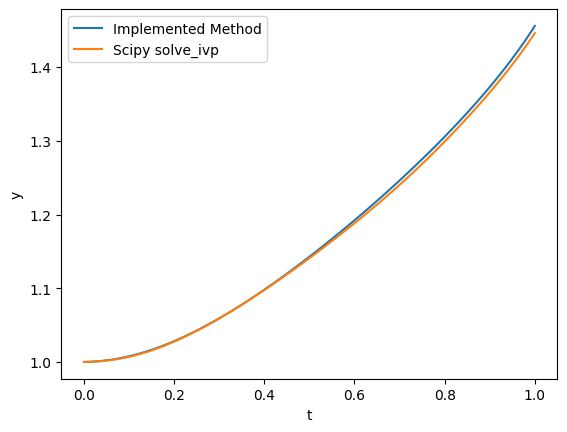

In [7]:
# Compare with scipy's solve_ivp
scipy_sol = sp.integrate.solve_ivp(lambda t, y: t/y*(1/np.sin(y**2))**2, [0,1], [1], t_eval=np.linspace(0,1,100))
plt.plot(t, y, label='Implemented Method')
plt.plot(scipy_sol.t, scipy_sol.y[0], label='Scipy solve_ivp')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.show()